
--- Reading Topography Grid: Topography Clipped 1m TIN.grd ---
Loaded GRD Grid Dimension: 5535x3469 pixels.
Spatial Bounds: X [412,188.0 to 417,723.0], Y [6,813,664.0 to 6,817,133.0]

--- Loading Point Cloud: Year 1 BM Points.txt ---
Successfully loaded 427,800 valid data coordinate rows.
Consolidating duplicate coordinates for point cloud...
Rasterizing point cloud to match the Topography GRD layout...
Calculating surface thickness variation...
Generating visual map plots...
Extracting change vector boundaries from active plot...


c:\Python\Personal\mcculloch-processors\.venv\Lib\site-packages\pyogrio\geopandas.py:917: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


Successfully exported Shapefile array to:
 -> h:\project\5359\QGIS\Mine Plans\Preprod to Year 1 Difference Raw.shp


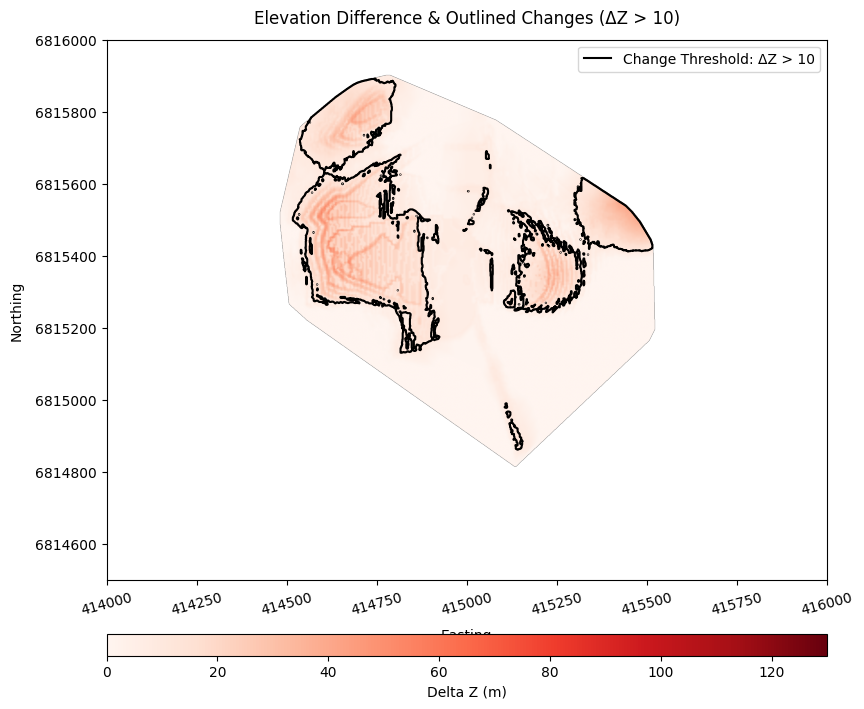

In [ ]:
# Enable interactive inline plotting inside Jupyter Notebook
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import os

# Spatial vector and raster libraries
import rasterio
import geopandas as gpd 
from shapely.geometry import Polygon
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Elevation difference threshold
THRESHOLD = 10  # meters

def load_point_txt(file_path):
    """Securely loads point cloud text files by leveraging Pandas auto-sniffing separator engine."""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Could not find file at: {file_path}")
        
    print(f"\n--- Loading Point Cloud: {os.path.basename(file_path)} ---")
    df = pd.read_csv(
        file_path, 
        sep=None,          
        engine='python',   
        names=['x', 'y', 'z'], 
        header=None,
        comment='#'
    )
    df['x'] = pd.to_numeric(df['x'], errors='coerce')
    df['y'] = pd.to_numeric(df['y'], errors='coerce')
    df['z'] = pd.to_numeric(df['z'], errors='coerce')
    df = df.dropna(subset=['x', 'y', 'z'])
    
    print(f"Successfully loaded {len(df):,} valid data coordinate rows.")
    return df

def process_mine_plans_with_grd(grd_path, txt_path, output_shp_path, tolerance=THRESHOLD):
    """
    Reads base topography, aligns a point cloud, maps differences,
    and generates a single integrated map overlaying delta Z and outlines.
    """
    # 1. Open the Topography .grd file using Rasterio
    if not os.path.exists(grd_path):
        raise FileNotFoundError(f"Could not find GRD file at: {grd_path}")
    print(f"\n--- Reading Topography Grid: {os.path.basename(grd_path)} ---")
    
    with rasterio.open(grd_path) as src:
        raster_preprod = src.read(1)
        transform = src.transform
        bounds = src.bounds
        width = src.width
        height = src.height
        raster_preprod = np.where(np.abs(raster_preprod) > 1e30, np.nan, raster_preprod)

    print(f"Loaded GRD Grid Dimension: {width}x{height} pixels.")
    print(f"Spatial Bounds: X [{bounds.left:,.1f} to {bounds.right:,.1f}], Y [{bounds.bottom:,.1f} to {bounds.top:,.1f}]")

    # 2. Generate 1D coordinate vectors tracking pixel center midpoints
    x_coords = np.arange(width) * transform[0] + bounds.left + (transform[0] / 2.0)
    y_coords = np.arange(height) * transform[4] + bounds.top + (transform[4] / 2.0)
    y_coords = np.sort(y_coords)

    # 3. Load and prepare point cloud
    df_points = load_point_txt(txt_path)
    print("Consolidating duplicate coordinates for point cloud...")
    df_points = df_points.groupby(['x', 'y'], as_index=False)['z'].mean()

    # 4. Interpolate point cloud data directly onto the exact GRD layout
    print("Rasterizing point cloud to match the Topography GRD layout...")
    raster = griddata(
        (df_points['x'], df_points['y']), 
        df_points['z'], 
        (x_coords[None, :], y_coords[:, None]), 
        method='linear'
    )

    # 5. Calculate Delta Z (Preprod GRD - Raster)
    print("Calculating surface thickness variation...")
    raster_diff = raster_preprod - raster
    
    # Isolate non-zero differences beyond noise threshold
    change_mask = np.where((raster_diff) > tolerance, 1, 0)
    change_mask[np.isnan(raster_diff)] = 0
    
    # 6. Rendering Consolidated Spatial Map & Capturing Contours
    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
    print("Generating visual map plots...")
    
    # Single plot setup
    fig, ax1 = plt.subplots(figsize=(10, 8))
    
    # Prevent scientific notation on axes
    ax1.ticklabel_format(style='plain', useOffset=False)
    plt.setp(ax1.get_xticklabels(), rotation=15)
    
    # Enforce your custom spatial window constraints and aspect locks
    ax1.set_xlim(414000, 416000)
    ax1.set_ylim(6814500, 6816000)
    ax1.set_aspect('equal', 'box')
    
    # Background Step: Plot the Cut vs Fill Change Map (Locked to 0-130 range)
    im1 = ax1.imshow(raster_diff, origin='lower', extent=extent, cmap='Reds', vmin=0, vmax=130)
    ax1.set_title(f'Elevation Difference & Outlined Changes (ΔZ > {tolerance})', pad=12)
    ax1.set_xlabel('Easting', labelpad=8)
    ax1.set_ylabel('Northing', labelpad=8)
    
    # Foreground Step: Overlay the contour outlines directly onto the same axis
    if np.any(change_mask == 1):
        grid_x, grid_y = np.meshgrid(x_coords, y_coords)
        cs = ax1.contour(grid_x, grid_y, change_mask, levels=[0.5], colors='black', linewidths=1.5)
        
        proxy_line = plt.Line2D([], [], color='black', lw=1.5, label=f'Change Threshold: ΔZ > {tolerance}')
        ax1.legend(handles=[proxy_line], loc='upper right')
        
        # --- EXPORT SHAPEFILE VECTOR LOGIC ---
        print("Extracting change vector boundaries from active plot...")
        polygons = []
        
        for level_segments in cs.allsegs:
            for segment in level_segments:
                if len(segment) >= 3:  
                    polygons.append(Polygon(segment))
                    
        if polygons:
            import geopandas as gpd  # Safetied internal check wrapper 
            gdf = gpd.GeoDataFrame(geometry=polygons)
            gdf.to_file(output_shp_path, driver="ESRI Shapefile")
            print(f"Successfully exported Shapefile array to:\n -> {output_shp_path}")
        else:
            print("Warning: No clean closed boundary shapes resolved to save.")
            
    else:
        print("Skipping export: No areas exceeded tolerance.")
    
    # --- AUTOMATED WORKAROUND FOR ASPECT LOCKS ---
    # Automatically tracks actual layout scaling boundaries to lock color bars down properly
    divider = make_axes_locatable(ax1)
    cbar_ax = divider.append_axes("bottom", size="4%", pad="10%")
    fig.colorbar(im1, cax=cbar_ax, label='Delta Z (m)', orientation='horizontal')
        
    plt.show()

# --- Execution Block ---
file_grd_topo = r"h:\project\5359\QGIS\Topography\Topography Clipped 1m TIN.grd"
file_points_txt = r"h:\project\5359\QGIS\Mine Plans\Year 1 BM Points.txt"
file_output_shp = r"h:\project\5359\QGIS\Mine Plans\Preprod to Year 1 Difference Raw.shp"

# Run the aligned pipeline
process_mine_plans_with_grd(
    file_grd_topo, 
    file_points_txt, 
    output_shp_path=file_output_shp, 
    tolerance=THRESHOLD
)